# 03 - Walk-Forward Day-Ahead Forecasting (per-Tag parallel)

**Lineup (alle Standorte identisch):**
- Point (Benchmark): Persistence, ARIMA(1,0,0), Elastic Net
- Probabilistisch (Hauptbeitrag): XGBoost Quantile, QGB, QRF -- je 5 Quantile (q10-q90)

Parallelisierung ueber Prognosetage (joblib/loky). SHAP pro Tree-Modell pro Standort als .pkl.

**Stepwise:** erst 1 Monat, dann 3 Monate, dann voll (2017-2025). Steuerung via Config-Zelle.

In [1]:
from __future__ import annotations
import warnings, sys, pickle, os
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from plot_utils import MODEL_COLORS, apply_style, get_model_color
apply_style()

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.gate_close_features import engineer_gate_close_features

DATA_PATH    = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
NWP_DIR      = PROJECT_ROOT / "data" / "raw" / "nwp"
RESULTS_DIR  = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
TABLES_DIR   = RESULTS_DIR / "tables"
FIGURES_DIR  = RESULTS_DIR / "figures"
SHAP_DIR     = RESULTS_DIR / "shap_explanations"
for d in [FORECAST_DIR, TABLES_DIR, FIGURES_DIR, SHAP_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print("Setup OK")

Setup OK


## Config (Stepwise steuern)

In [2]:
# ===== CONFIG =====
SELECTED_PLANTS   = ["Schonungen", "Schwanfeld", "Trabelsdorf", "Obbach"]
FULL_PERIOD       = True            # True: pro Standort die GESAMTE verfuegbare Spanne (auto)
TEST_START        = "2023-01-01"    # nur genutzt wenn FULL_PERIOD = False (Stepwise-Tests)
TEST_END          = "2023-02-01"
TRAIN_WINDOW_DAYS = 30
QUANTILES         = [0.1, 0.25, 0.5, 0.75, 0.9]
N_JOBS            = -1              # alle Cores (loky)
TARGET            = "energy_mwh"
TAU_STAR          = 0.5429          # optimal_quantile(c_under, c_over) aus NB04 (reBAP vs. DA-Preise),
                                     # hier fest hinterlegt um NB03 unabhaengig von der Preis-Pipeline zu halten.
                                     # Nur fuer die zusaetzliche QGB@tau*-SHAP-Erklaerung (Abschnitt 4.5) genutzt --
                                     # NICHT fuer die Bidding-Logik (die weiterhin ueber qbid()-Interpolation in NB04 laeuft).

print("Plants:", SELECTED_PLANTS)
print("Full period (auto pro Standort):", FULL_PERIOD)
print("Quantiles:", QUANTILES)
print("Tau* (fuer QGB-SHAP):", TAU_STAR)

Plants: ['Schonungen', 'Schwanfeld', 'Trabelsdorf', 'Obbach']
Full period (auto pro Standort): True
Quantiles: [0.1, 0.25, 0.5, 0.75, 0.9]
Tau* (fuer QGB-SHAP): 0.5429


## 1. Daten + 3-Layer-Features (alle Standorte, Filter via SELECTED_PLANTS)

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values(["site", "timestamp"]).reset_index(drop=True)
if "energy_mwh" not in df.columns:
    df["energy_mwh"] = df["power"] / 1000

df = engineer_gate_close_features(df, lookback_days=8)

dfs_nwp = {}
for site in df["site"].unique():
    p = NWP_DIR / f"nwp_{site.lower()}.csv"
    if p.exists():
        dfs_nwp[site] = pd.read_csv(p, parse_dates=["timestamp"])

merged = []
for site in sorted(df["site"].unique()):
    ds = df[df["site"] == site].copy()
    if site in dfs_nwp:
        ds = pd.merge(ds, dfs_nwp[site], on="timestamp", how="left")
    merged.append(ds)
df = pd.concat(merged, ignore_index=True).sort_values(["site", "timestamp"]).reset_index(drop=True)

# v^3-Proxy (physikalische Leistungskurve P ~ v^3) -- gibt linearen Modellen den dominanten nichtlinearen Term direkt
if "nwp_ws100" in df.columns:
    df["nwp_ws100_cubed"] = df["nwp_ws100"] ** 3

TIME_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
GATE_CLOSE_FEATURES = ["energy_at_gate", "energy_gate_m12h", "energy_gate_m24h", "energy_gate_m48h", "energy_gate_m168h",
    "energy_roll24_at_gate", "energy_roll_std24_at_gate", "energy_roll168_at_gate", "energy_roll_std168_at_gate",
    "wind_at_gate", "wind_gate_m12h", "wind_gate_m24h", "wind_gate_m168h",
    "wind_roll24_at_gate", "wind_roll_std24_at_gate", "wind_roll168_at_gate", "wind_roll_std168_at_gate"]
NWP_FEATURES = ["nwp_ws100", "nwp_ws100_cubed", "nwp_wd100", "nwp_temp2m", "nwp_cloud_cover"]
FEATURES = [f for f in (TIME_FEATURES + GATE_CLOSE_FEATURES + NWP_FEATURES) if f in df.columns]

print("Data:", df.shape, "| Sites:", sorted(df["site"].unique()))
print("Features:", len(FEATURES))

Data: (262827, 38) | Sites: ['Obbach', 'Schonungen', 'Schwanfeld', 'Trabelsdorf']
Features: 26


## 2. Worker: simulate_day (self-contained, loky-safe)

In [4]:
def simulate_day(args):
    """Self-contained Worker fuer EINEN Prognosetag (loky-safe).
    args = (site, X_train, y_train, X_val, y_val, ts_val, QUANTILES)
    Returns (pred_df, shap_dict) oder None.
    """
    import os
    os.environ["OMP_NUM_THREADS"] = "1"
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import ElasticNet, QuantileRegressor
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    import xgboost as xgb
    from statsmodels.tsa.arima.model import ARIMA
    import shap

    site, X_train, y_train, X_val, y_val, ts_val, QUANTILES = args
    n = len(X_val)
    if len(X_train) < 24 or n == 0:
        return None

    point = {}
    quant = {}   # {model: {q: array}}
    shp = {}     # {model: shap_array (q50)}

    # === POINT (Benchmark) ===
    point["persistence"] = np.clip(y_train[-n:], 0, None) if len(y_train) >= n else np.full(n, y_train[-1])
    try:
        am = ARIMA(y_train, order=(1, 0, 0)).fit()
        # predicted_mean ist bei ndarray-Input ein ndarray (kein .values!) -> np.asarray deckt beide Faelle ab
        point["arima"] = np.clip(np.asarray(am.get_forecast(steps=n).predicted_mean), 0, None)
    except Exception:
        point["arima"] = point["persistence"]
    try:
        en = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42).fit(X_train, y_train)
        point["elastic_net"] = np.clip(en.predict(X_val), 0, None)
    except Exception:
        point["elastic_net"] = point["persistence"]

    # === XGBoost Quantile (pro Quantil ein Modell) ===
    quant["xgb"] = {}
    xgb_med = None
    for q in QUANTILES:
        m = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                             objective="reg:quantileerror", quantile_alpha=q,
                             tree_method="hist", n_jobs=1, random_state=42, verbosity=0)
        m.fit(X_train, y_train)
        quant["xgb"][q] = np.clip(m.predict(X_val), 0, None)
        if abs(q - 0.5) < 1e-9:
            xgb_med = m

    # === QGB (Gradient Boosting Quantile) ===
    quant["qgb"] = {}
    qgb_med = None
    for q in QUANTILES:
        m = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05,
                                      loss="quantile", alpha=q, subsample=0.8, random_state=42)
        m.fit(X_train, y_train)
        quant["qgb"][q] = np.clip(m.predict(X_val), 0, None)
        if abs(q - 0.5) < 1e-9:
            qgb_med = m

    # === QGB bei tau* (zusaetzliches Modell NUR fuer SHAP-Interpretierbarkeit, Abschnitt 4.5;
    # fliesst NICHT in predictions_*.csv / Bidding ein -- die Gebotslogik nutzt weiterhin die
    # qbid()-Interpolation zwischen q50/q75 in NB04, unveraendert) ===
    TAU_STAR = 0.5429  # optimal_quantile(c_under, c_over) aus NB04, hier fest hinterlegt (self-contained Worker)
    qgb_taustar = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05,
                                            loss="quantile", alpha=TAU_STAR, subsample=0.8, random_state=42)
    qgb_taustar.fit(X_train, y_train)

    # === QRF (ein Forest, Quantile aus Einzelbaeumen) ===
    qrf = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=5,
                                n_jobs=1, random_state=42).fit(X_train, y_train)
    tree_preds = np.stack([t.predict(X_val) for t in qrf.estimators_], axis=0)
    quant["qrf"] = {}
    for q in QUANTILES:
        quant["qrf"][q] = np.clip(np.percentile(tree_preds, q * 100, axis=0), 0, None)

    # === QR (Lineare Quantile Regression) -- Koeffizienten = native Erklaerung (kein SHAP noetig) ===
    quant["qr"] = {}
    qr_coefs = {}
    for q in QUANTILES:
        try:
            m = QuantileRegressor(quantile=q, alpha=0.01, solver="highs")
            m.fit(X_train, y_train)
            quant["qr"][q] = np.clip(m.predict(X_val), 0, None)
            qr_coefs[q] = np.asarray(m.coef_, dtype=float)
        except Exception:
            quant["qr"][q] = point["elastic_net"]
            qr_coefs[q] = np.full(X_train.shape[1], np.nan)

    # Monotonie erzwingen (kein Quantile-Crossing)
    for mdl in quant:
        arr = np.sort(np.stack([quant[mdl][q] for q in QUANTILES], axis=1), axis=1)
        for j, q in enumerate(QUANTILES):
            quant[mdl][q] = arr[:, j]

    # === SHAP (q50-Modelle + QGB@tau*) + base value (X_val wird vom Driver mitgespeichert) ===
    for name, model in [("xgb", xgb_med), ("qgb", qgb_med), ("qrf", qrf), ("qgb_taustar", qgb_taustar)]:
        try:
            ex = shap.TreeExplainer(model)
            sv = ex.shap_values(X_val)
            bv = ex.expected_value
            if isinstance(bv, (list, np.ndarray)):
                bv = float(np.mean(bv))
            shp[name] = {"shap": sv, "base": float(bv)}
        except Exception:
            shp[name] = None

    # === Prediction-DataFrame fuer diesen Tag ===
    row = {"site": site, "timestamp": ts_val, "y_true": y_val}
    for pname, arr in point.items():
        row[pname] = arr
    for mdl in ["xgb", "qgb", "qrf", "qr"]:
        for q in QUANTILES:
            row[f"{mdl}_q{int(q * 100):02d}"] = quant[mdl][q]
    pred_df = pd.DataFrame(row)

    return pred_df, shp, X_val, qr_coefs

## 3. Day-Args Builder

In [5]:
def build_day_args(plant, dfp, FEATURES, TARGET, QUANTILES, train_days, test_start, test_end):
    dfp = dfp.sort_values("timestamp").dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
    if len(dfp) == 0:
        return []
    X = dfp[FEATURES].values
    y = dfp[TARGET].values
    tsv = dfp["timestamp"].values
    days = pd.date_range(test_start, test_end, freq="D")
    args = []
    for d in days:
        d0 = np.datetime64(pd.Timestamp(d))
        d1 = d0 + np.timedelta64(24, "h")
        tr0 = d0 - np.timedelta64(int(train_days), "D")
        tr = (tsv >= tr0) & (tsv < d0)
        va = (tsv >= d0) & (tsv < d1)
        if tr.sum() < 24 or va.sum() == 0:
            continue
        args.append((plant, X[tr], y[tr], X[va], y[va], tsv[va], QUANTILES))
    return args

print("build_day_args ready")

build_day_args ready


## 4. Parallel-Simulation pro Standort + Speichern (Predictions + SHAP)

In [6]:
import time
all_predictions = {}

for plant in SELECTED_PLANTS:
    t0 = time.time()
    dfp = df[df["site"] == plant].copy()

    if FULL_PERIOD:
        valid = dfp.dropna(subset=FEATURES + [TARGET])
        if len(valid) == 0:
            print(f"{plant}: keine validen Daten, skip"); continue
        ts_start = valid["timestamp"].min() + pd.Timedelta(days=TRAIN_WINDOW_DAYS)
        ts_end   = valid["timestamp"].max()
    else:
        ts_start, ts_end = TEST_START, TEST_END

    args = build_day_args(plant, dfp, FEATURES, TARGET, QUANTILES, TRAIN_WINDOW_DAYS, ts_start, ts_end)
    print(f"{plant}: {pd.Timestamp(ts_start).date()} -> {pd.Timestamp(ts_end).date()}, {len(args)} Tage (n_jobs={N_JOBS}) ...")

    results = Parallel(n_jobs=N_JOBS, backend="loky")(delayed(simulate_day)(a) for a in args)
    results = [r for r in results if r is not None]

    predictions = pd.concat([r[0] for r in results], ignore_index=True)
    out_csv = FORECAST_DIR / f"predictions_{plant.lower()}.csv"
    predictions.to_csv(out_csv, index=False)

    rng = np.random.default_rng(42)
    for mdl in ["xgb", "qgb", "qrf", "qgb_taustar"]:
        sv_l, X_l, ts_l, base_l = [], [], [], []
        for r in results:
            shp = r[1]
            if shp.get(mdl) is not None:
                sv_l.append(shp[mdl]["shap"]); X_l.append(r[2])
                ts_l.append(r[0]["timestamp"].values); base_l.append(shp[mdl]["base"])
        if sv_l:
            sv = np.concatenate(sv_l, axis=0); X = np.concatenate(X_l, axis=0)
            ts = np.concatenate(ts_l, axis=0); base = float(np.mean(base_l))
            if len(sv) > 5000:
                idx = np.sort(rng.choice(len(sv), 5000, replace=False))
                sv, X, ts = sv[idx], X[idx], ts[idx]
            with open(SHAP_DIR / f"shap_{mdl}_{plant.lower()}.pkl", "wb") as f:
                pickle.dump({"shap_values": sv, "X": X, "feature_names": FEATURES,
                             "base_value": base, "timestamps": ts}, f)

    # QR-Koeffizienten aggregieren (Mittel ueber Walk-Forward) -- native Interpretation der QR
    qr_rows = []
    for q in QUANTILES:
        coefs = np.array([r[3][q] for r in results if r[3].get(q) is not None])
        if len(coefs):
            mean_b = np.nanmean(coefs, axis=0); std_b = np.nanstd(coefs, axis=0)
            for fi, fname in enumerate(FEATURES):
                qr_rows.append({"feature": fname, "quantile": q, "beta_mean": float(mean_b[fi]), "beta_std": float(std_b[fi])})
    pd.DataFrame(qr_rows).to_csv(TABLES_DIR / f"qr_coefficients_{plant.lower()}.csv", index=False)

    all_predictions[plant] = predictions
    print(f"  {plant}: {len(predictions)} rows, {time.time()-t0:.0f}s -> {out_csv.name}")

print("Simulation done.")

Schonungen: 2017-01-31 -> 2025-08-31, 3111 Tage (n_jobs=-1) ...


  Schonungen: 74313 rows, 948s -> predictions_schonungen.csv


Schwanfeld: 2017-01-31 -> 2025-08-31, 3126 Tage (n_jobs=-1) ...


  Schwanfeld: 74933 rows, 900s -> predictions_schwanfeld.csv


Trabelsdorf: 2017-04-22 -> 2025-08-31, 3050 Tage (n_jobs=-1) ...


  Trabelsdorf: 73021 rows, 932s -> predictions_trabelsdorf.csv
Obbach: 2023-01-31 -> 2024-01-01, 336 Tage (n_jobs=-1) ...


  Obbach: 8040 rows, 104s -> predictions_obbach.csv
Simulation done.


## 5. ARIMA / Elastic Net Gate (Verbesserung ueber Persistence?)

In [7]:
from sklearn.metrics import mean_absolute_error
print("=== Point-Benchmark MAE (vs Persistence) ===")
for plant, pred in all_predictions.items():
    y = pred["y_true"].values
    mae_p = mean_absolute_error(y, pred["persistence"].values)
    print(f"{plant}:")
    for m in ["persistence", "arima", "elastic_net"]:
        if m in pred.columns:
            mae = mean_absolute_error(y, pred[m].values)
            impr = 100 * (mae_p - mae) / mae_p if mae_p > 0 else 0.0
            print(f"  {m:<14} MAE={mae:.4f}  ({impr:+.1f}% vs persistence)")
print()
print("Hinweis: <~2% Verbesserung -> ARIMA/EN nur im Grundlagenkapitel, raus aus Vollsim.")

=== Point-Benchmark MAE (vs Persistence) ===
Schonungen:
  persistence    MAE=0.3494  (+0.0% vs persistence)
  arima          MAE=0.2841  (+18.7% vs persistence)
  elastic_net    MAE=0.1817  (+48.0% vs persistence)
Schwanfeld:
  persistence    MAE=0.6092  (+0.0% vs persistence)
  arima          MAE=0.5156  (+15.4% vs persistence)
  elastic_net    MAE=0.3725  (+38.9% vs persistence)
Trabelsdorf:
  persistence    MAE=0.5546  (+0.0% vs persistence)
  arima          MAE=0.4367  (+21.3% vs persistence)
  elastic_net    MAE=0.3014  (+45.7% vs persistence)
Obbach:
  persistence    MAE=0.6048  (+0.0% vs persistence)
  arima          MAE=0.5059  (+16.3% vs persistence)
  elastic_net    MAE=0.3506  (+42.0% vs persistence)

Hinweis: <~2% Verbesserung -> ARIMA/EN nur im Grundlagenkapitel, raus aus Vollsim.


## 6. Pinball Loss (alle Quantile + Modelle)

In [8]:
def pinball(y, yp, q):
    e = y - yp
    return np.mean(np.maximum(q * e, (q - 1) * e))

PROB = ["xgb", "qgb", "qrf", "qr"]
rows = []
for plant, pred in all_predictions.items():
    y = pred["y_true"].values
    for mdl in PROB:
        for q in QUANTILES:
            col = f"{mdl}_q{int(q*100):02d}"
            if col in pred.columns:
                rows.append({"plant": plant, "model": mdl, "quantile": q,
                             "pinball_loss": float(pinball(y, pred[col].values, q))})
pinball_df = pd.DataFrame(rows)
pinball_df.to_csv(TABLES_DIR / "pinball_evaluation.csv", index=False)
print("Mean Pinball je Modell (CRPS-Proxy):")
print(pinball_df.groupby("model")["pinball_loss"].mean().round(4))

Mean Pinball je Modell (CRPS-Proxy):
model
qgb    0.0984
qr     0.1014
qrf    0.1023
xgb    0.1002
Name: pinball_loss, dtype: float64


## 7. Viz A: Forecast vs. Actual (Beispielmonat, stuendlich)

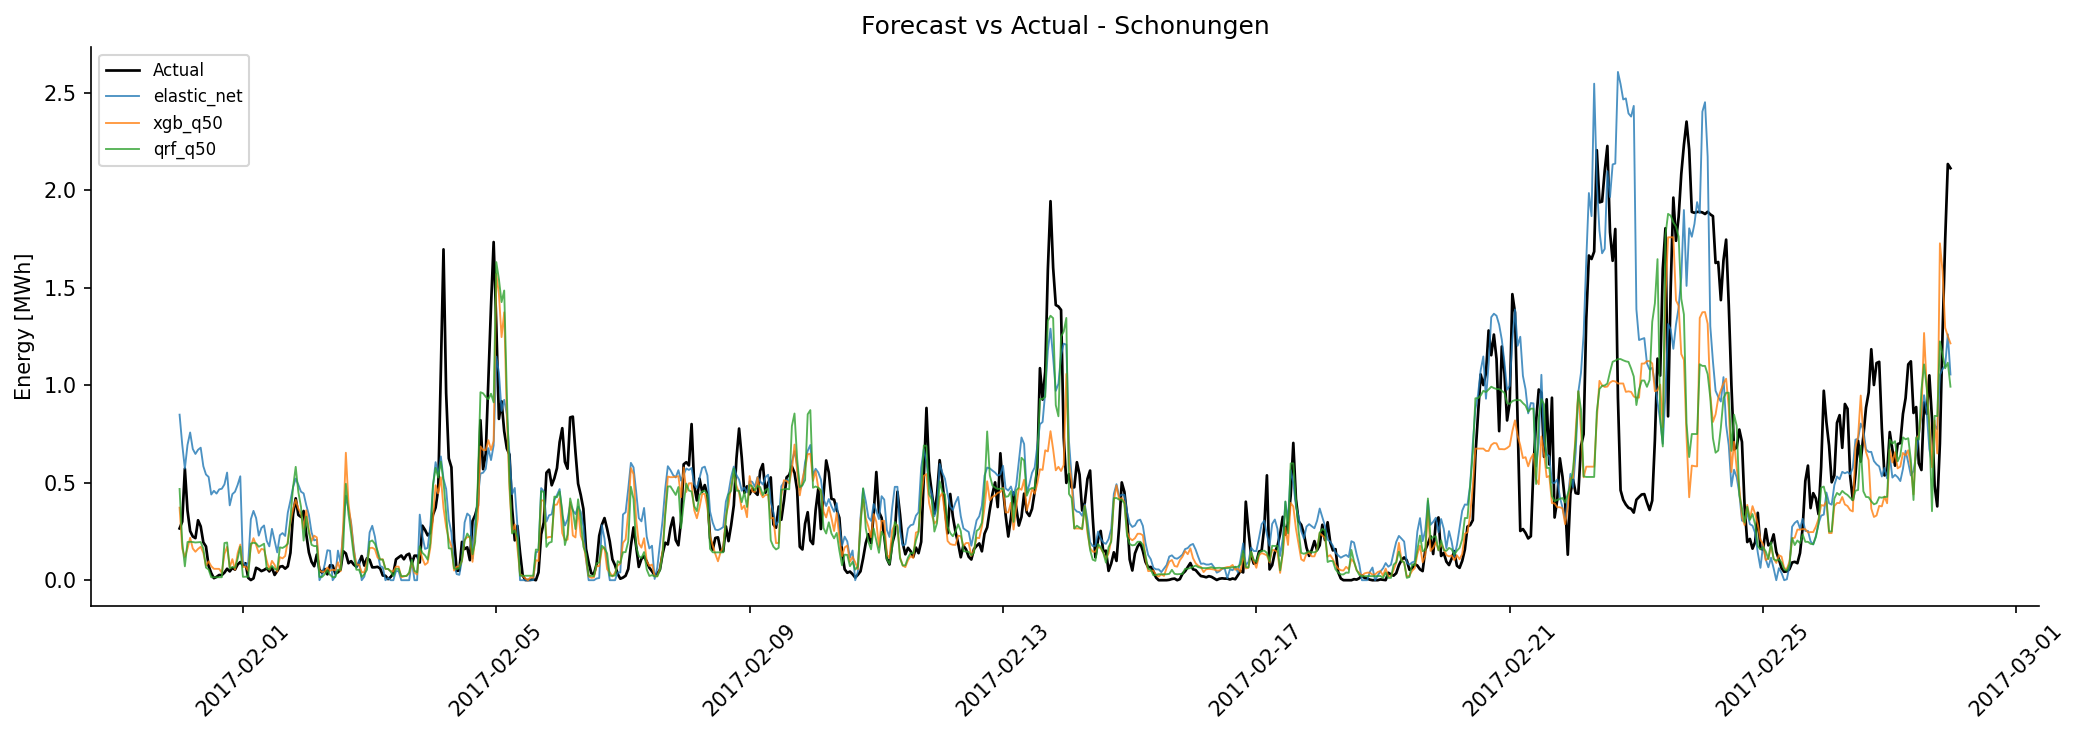

In [9]:
PLOT_PLANT = SELECTED_PLANTS[0]
pred = all_predictions[PLOT_PLANT].sort_values("timestamp").reset_index(drop=True)
m = pred.iloc[:28*24]   # erste ~4 Wochen
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(m["timestamp"], m["y_true"], color="black", lw=1.3, label="Actual")
for col, c in [("elastic_net", MODEL_COLORS["elastic_net"]), ("xgb_q50", MODEL_COLORS["xgb"]), ("qrf_q50", MODEL_COLORS["qrf"])]:
    if col in m.columns:
        ax.plot(m["timestamp"], m[col], lw=0.9, alpha=0.8, label=col)
ax.set_title(f"Forecast vs Actual - {PLOT_PLANT}")
ax.set_ylabel("Energy [MWh]"); ax.legend(fontsize=8); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"forecast_vs_actual_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 8. Viz B: Quantil-Baender (q10-q90)

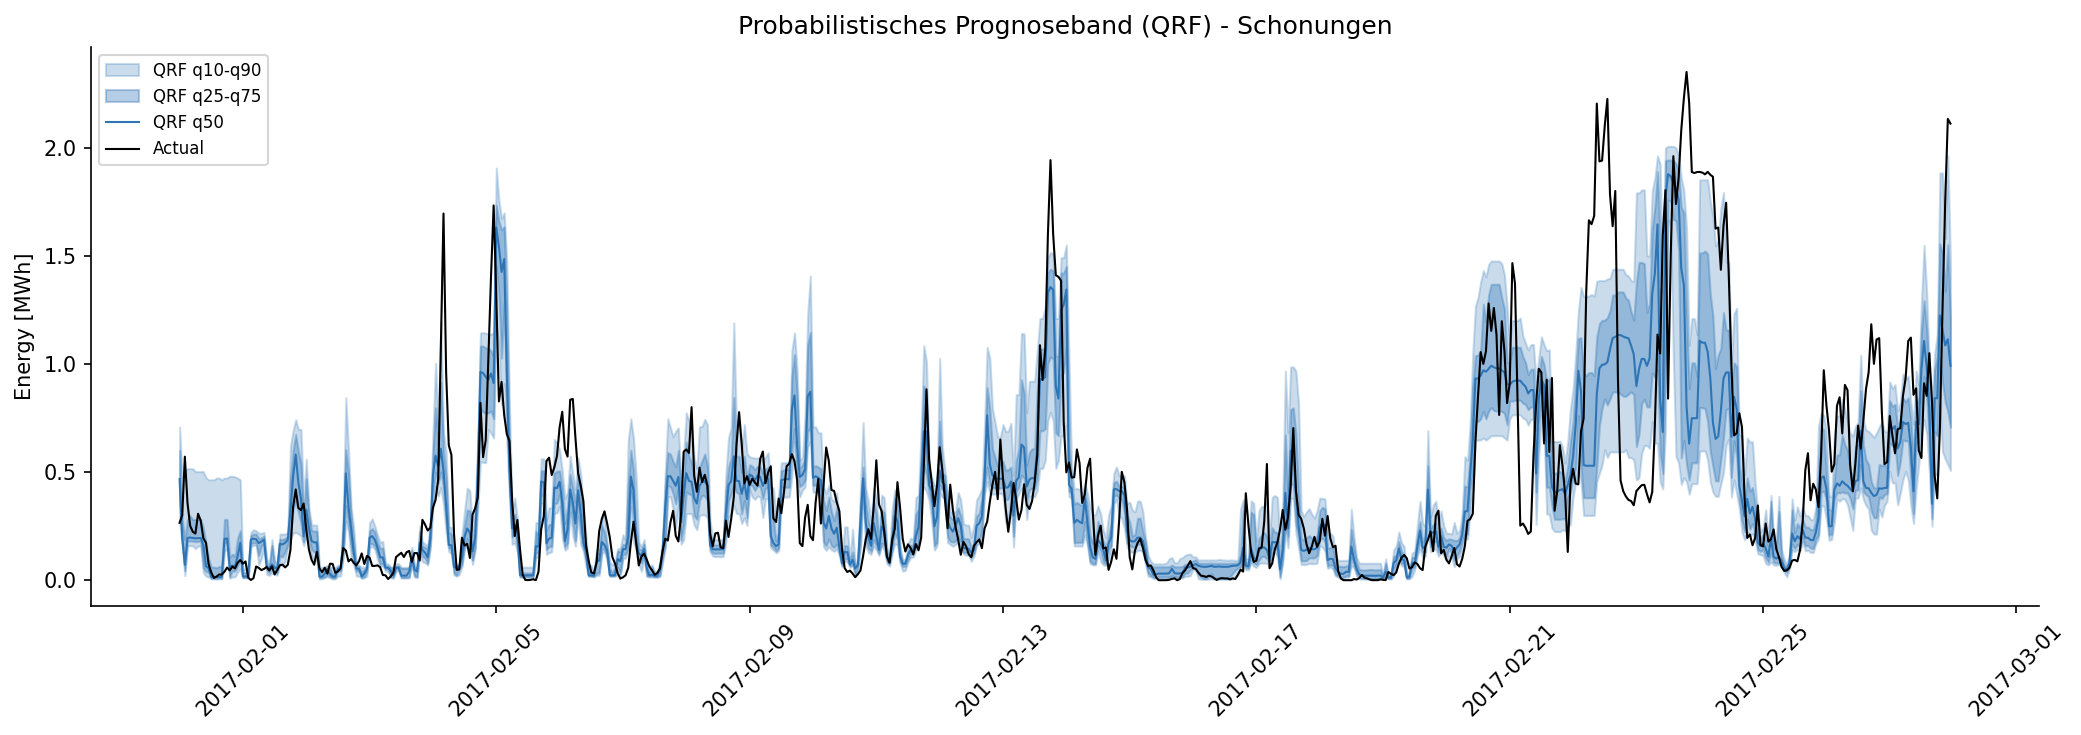

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(m["timestamp"], m["qrf_q10"], m["qrf_q90"], alpha=0.25, color=MODEL_COLORS["qrf"], label="QRF q10-q90")
ax.fill_between(m["timestamp"], m["qrf_q25"], m["qrf_q75"], alpha=0.35, color=MODEL_COLORS["qrf"], label="QRF q25-q75")
ax.plot(m["timestamp"], m["qrf_q50"], color=MODEL_COLORS["qrf"], lw=1.0, label="QRF q50")
ax.plot(m["timestamp"], m["y_true"], color="black", lw=1.0, label="Actual")
ax.set_title(f"Probabilistisches Prognoseband (QRF) - {PLOT_PLANT}")
ax.set_ylabel("Energy [MWh]"); ax.legend(fontsize=8); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"quantile_band_qrf_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 9. Viz C: Pinball Loss ueber Quantile + Modelle

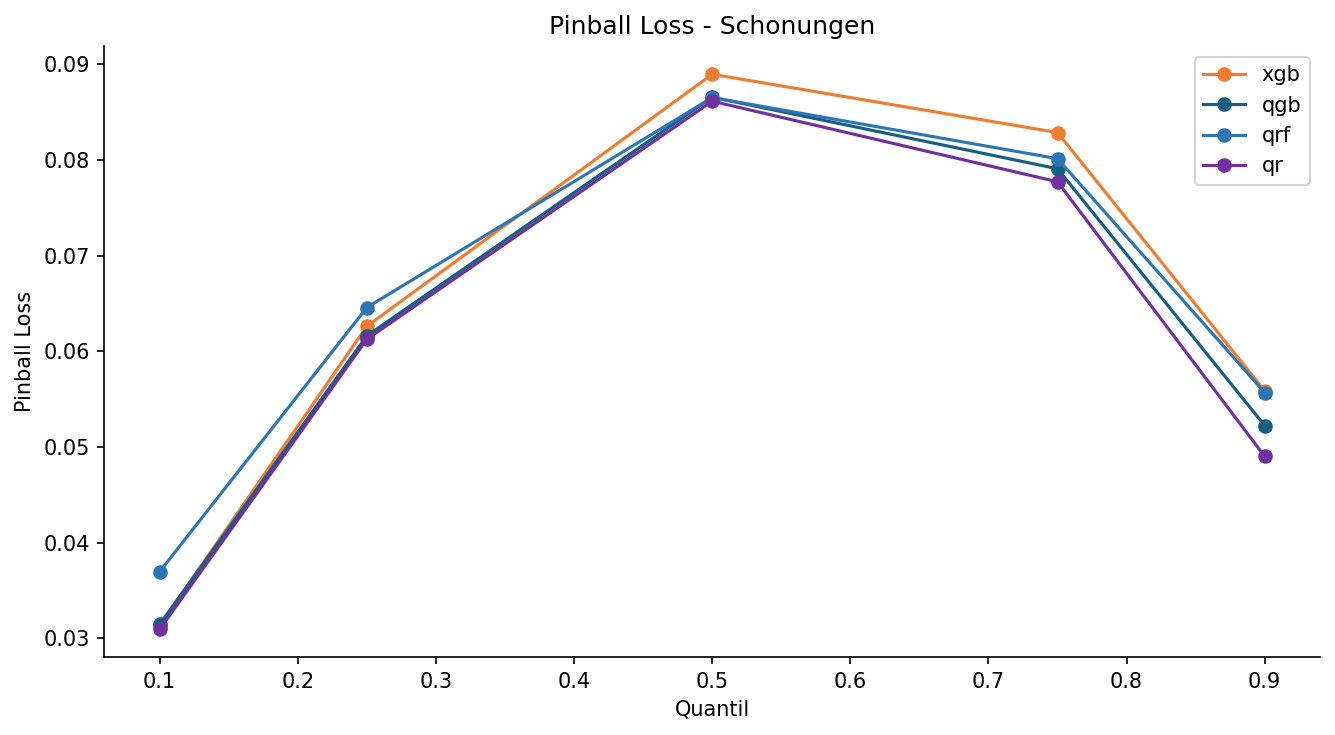

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sub = pinball_df[pinball_df["plant"] == PLOT_PLANT]
for mdl, c in [("xgb", MODEL_COLORS["xgb"]), ("qgb", MODEL_COLORS["qgb"]), ("qrf", MODEL_COLORS["qrf"]), ("qr", MODEL_COLORS["qr"])]:
    s = sub[sub["model"] == mdl].sort_values("quantile")
    if len(s):
        ax.plot(s["quantile"], s["pinball_loss"], marker="o", label=mdl, color=c)
ax.set_xlabel("Quantil"); ax.set_ylabel("Pinball Loss"); ax.set_title(f"Pinball Loss - {PLOT_PLANT}")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"pinball_loss_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 10. Viz D: Scatter Actual vs. Predicted (pro Modell)

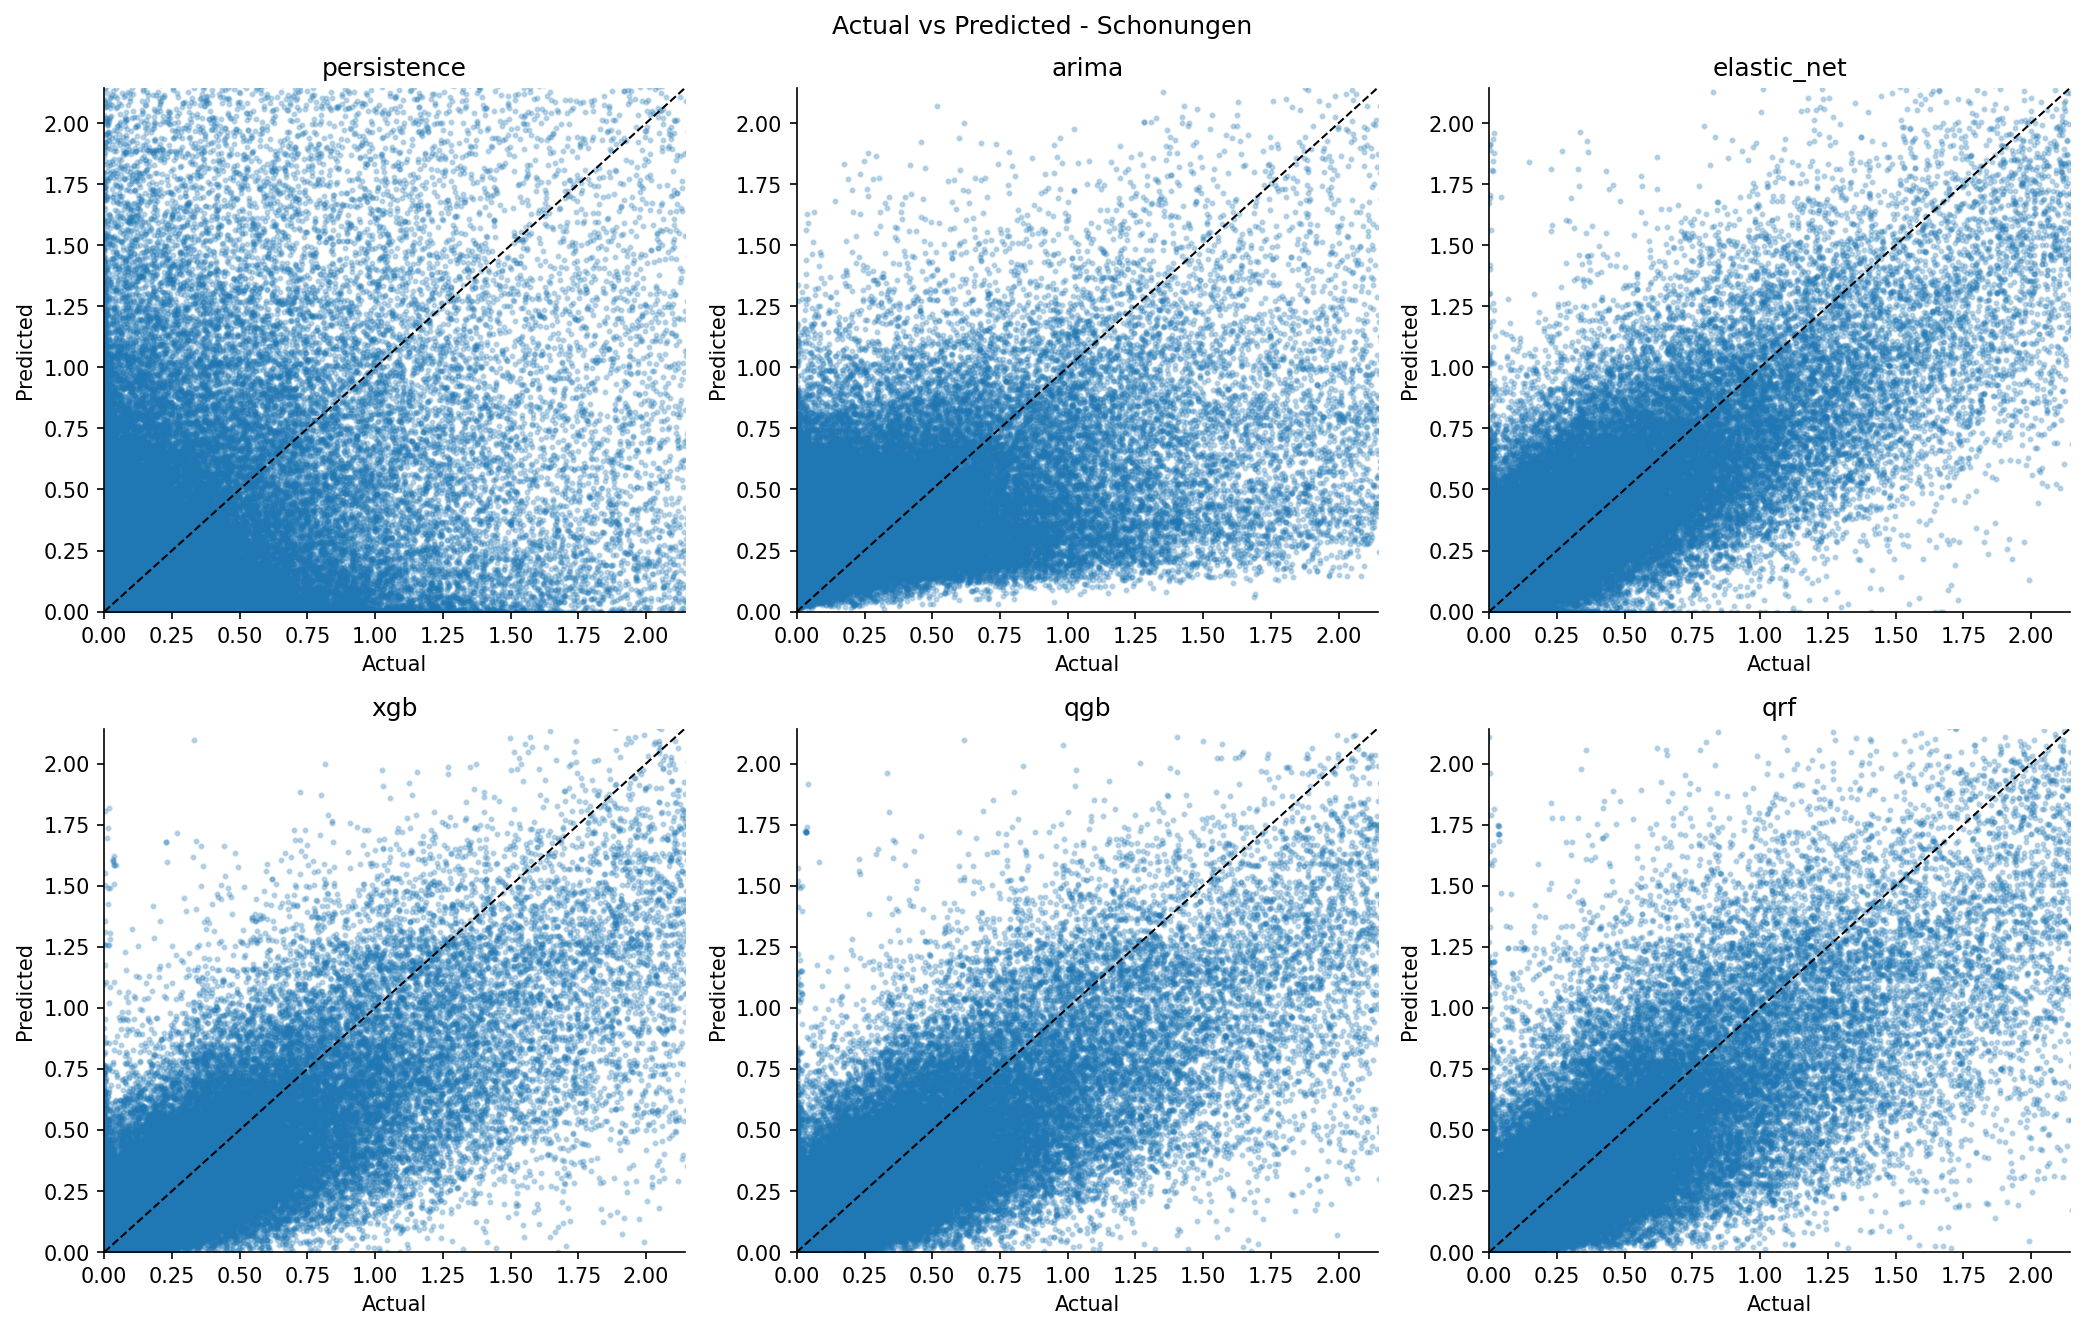

In [12]:
scatter_models = [("persistence","persistence"),("arima","arima"),("elastic_net","elastic_net"),
                  ("xgb_q50","xgb"),("qgb_q50","qgb"),("qrf_q50","qrf")]
scatter_models = [(c, n) for c, n in scatter_models if c in pred.columns]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
y = pred["y_true"].values
lim = max(1e-6, float(np.nanpercentile(y, 99)))
for ax, (col, name) in zip(axes.ravel(), scatter_models):
    yp = pred[col].values
    ax.scatter(y, yp, s=4, alpha=0.25, color="#1f77b4")
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(name); ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
for ax in axes.ravel()[len(scatter_models):]:
    ax.axis("off")
plt.suptitle(f"Actual vs Predicted - {PLOT_PLANT}"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"scatter_actual_pred_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 10. Viz E: Cross Site RMSE Vergleich


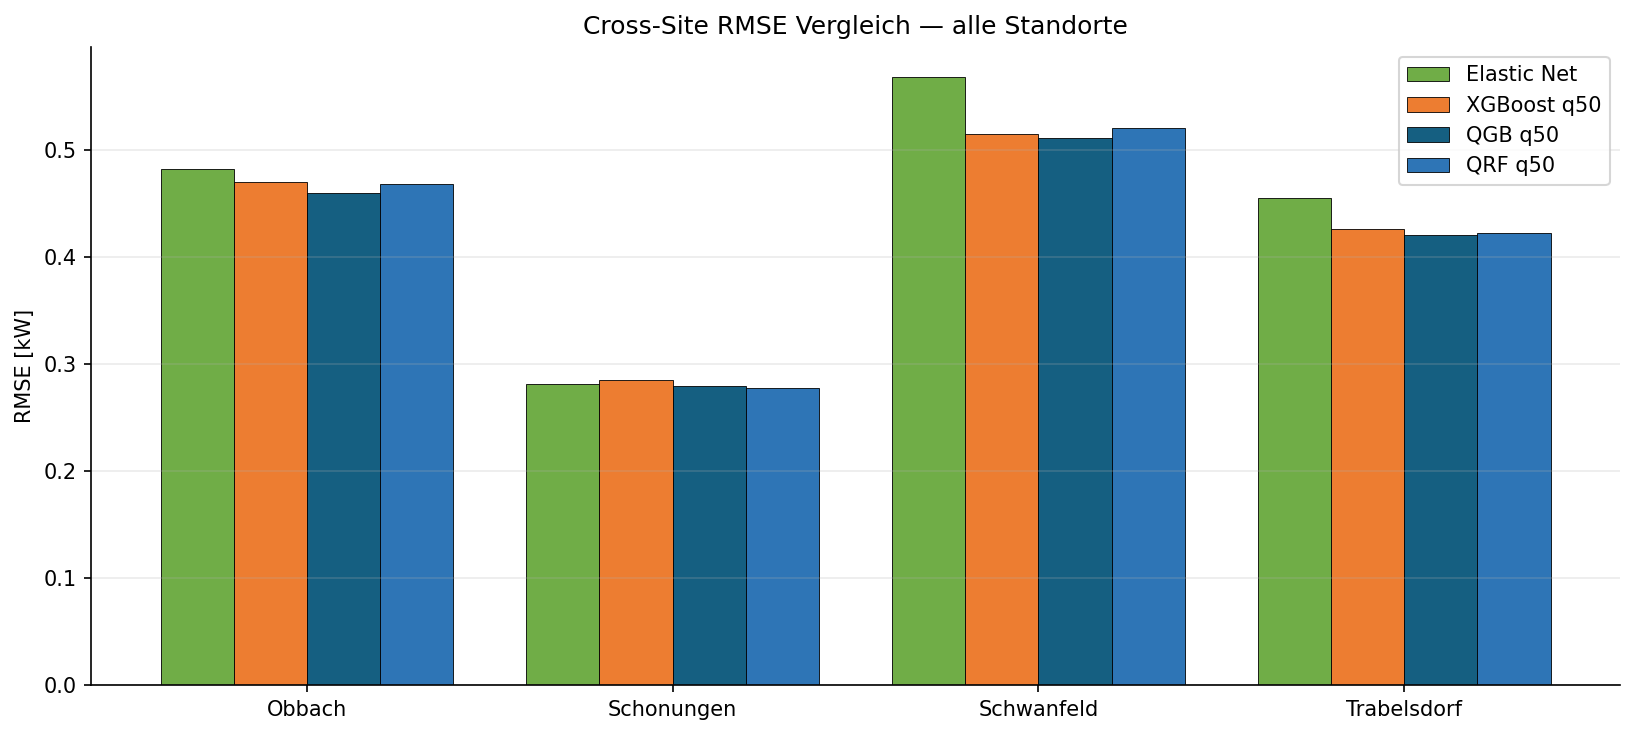

In [13]:
# Erst wenn alle 4 Standorte durchgelaufen sind
site_metrics = []

for plant, pred in all_predictions.items():
    for col, label in [
        ("elastic_net", "Elastic Net"),
        ("xgb_q50", "XGBoost q50"),
        ("qgb_q50", "QGB q50"),
        ("qrf_q50", "QRF q50"),
    ]:
        if col not in pred.columns:
            continue

        valid = pred[col].notna()
        y_t = pred.loc[valid, "y_true"].values
        y_p = pred.loc[valid, col].values

        site_metrics.append({
            "site": plant,
            "model": label,
            "RMSE": np.sqrt(np.mean((y_p - y_t) ** 2)),
            "R2": 1 - np.sum((y_p - y_t) ** 2) / np.sum((y_t - y_t.mean()) ** 2),
        })

metrics_df = pd.DataFrame(site_metrics)

fig, ax = plt.subplots(figsize=(11, 5))

sites = sorted(metrics_df["site"].unique())
models = metrics_df["model"].unique()

x = np.arange(len(sites))
width = 0.2

for j, m in enumerate(models):
    vals = [
        metrics_df[
            (metrics_df["site"] == s) &
            (metrics_df["model"] == m)
        ]["RMSE"].values[0]
        for s in sites
    ]

    ax.bar(
        x + j * width,
        vals,
        width,
        label=m,
        color=get_model_color(m),
        edgecolor="black",
        linewidth=0.4,
    )

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(sites)
ax.set_ylabel("RMSE [kW]")
ax.set_title("Cross-Site RMSE Vergleich — alle Standorte")
ax.legend()

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cross_site_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Viz F: Reliability Diagram (Kalibriertheit der Quantile)

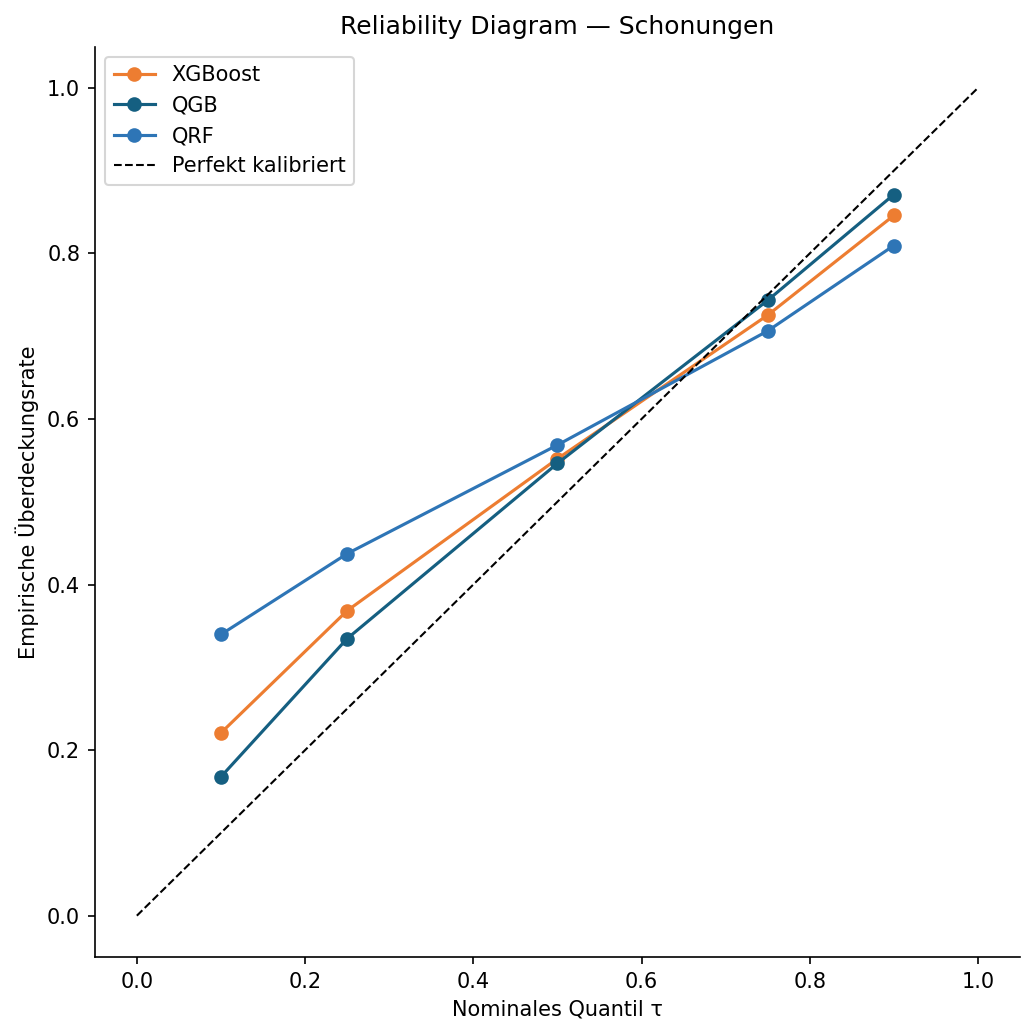

In [14]:
fig, ax = plt.subplots(figsize=(7,7))
pred = all_predictions[PLOT_PLANT]

for prefix, label, color in [("xgb","XGBoost", MODEL_COLORS["xgb"]), 
                               ("qgb","QGB", MODEL_COLORS["qgb"]), 
                               ("qrf","QRF",MODEL_COLORS["qrf"]),]:
    coverage = []
    for q in QUANTILES:
        col = f"{prefix}_q{int(q*100):02d}"
        if col not in pred.columns: continue
        valid = pred[col].notna()
        actual_coverage = float(np.mean(pred.loc[valid,"y_true"].values 
                                        <= pred.loc[valid,col].values))
        coverage.append((q, actual_coverage))
    if coverage:
        qs, covs = zip(*coverage)
        ax.plot(qs, covs, marker="o", label=label, color=color)

ax.plot([0,1],[0,1],"k--",linewidth=1,label="Perfekt kalibriert")
ax.set_xlabel("Nominales Quantil τ")
ax.set_ylabel("Empirische Überdeckungsrate")
ax.set_title(f"Reliability Diagram — {PLOT_PLANT}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"reliability_{PLOT_PLANT.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Viz G: Drei Beispieltage (windig / durchschnittlich / ruhig)

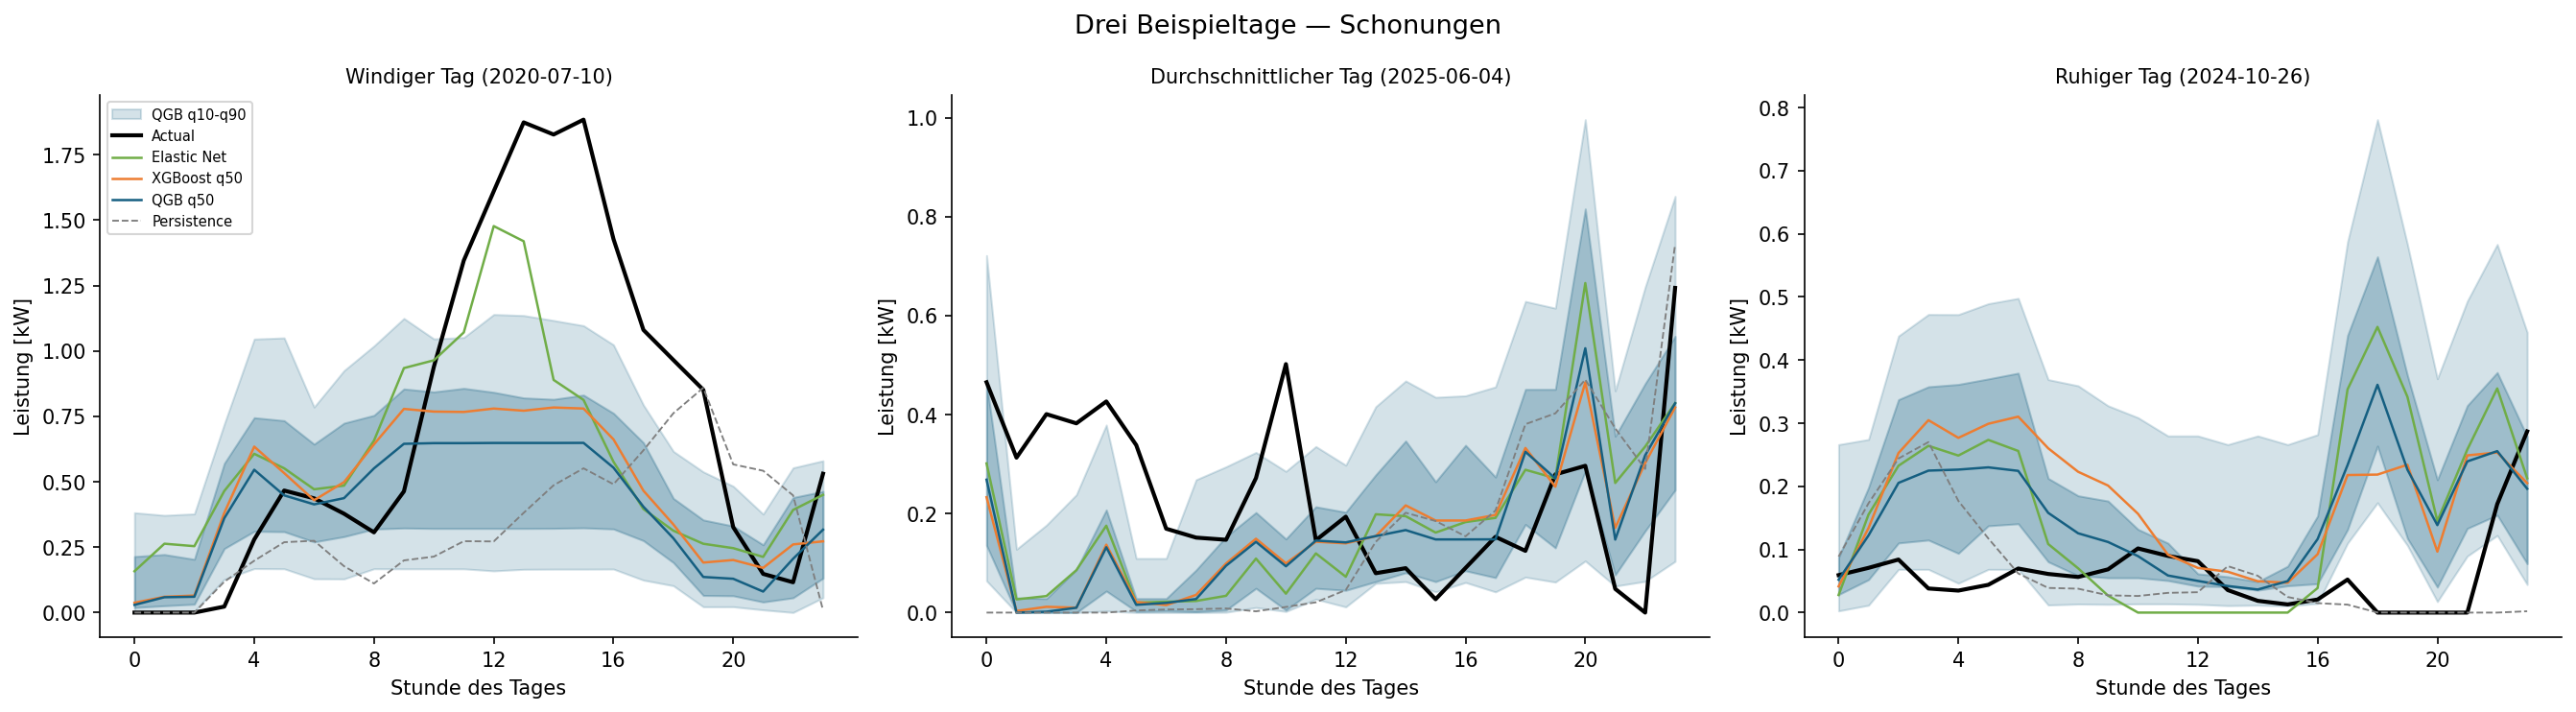

In [15]:


pred = all_predictions[PLOT_PLANT].copy()
pred["timestamp"] = pd.to_datetime(pred["timestamp"])
pred["date"]      = pred["timestamp"].dt.date

# Tagesmittel der tatsaechlichen Produktion berechnen
daily_mean = pred.groupby("date")["y_true"].mean()
q_low  = float(daily_mean.quantile(0.15))
q_mid  = float(daily_mean.quantile(0.50))
q_high = float(daily_mean.quantile(0.85))

def pick_day(target_q, label):
    candidates = daily_mean[(daily_mean - target_q).abs().sort_values().index[:30]]
    for d in candidates.index:
        day_data = pred[pred["date"] == d]
        if len(day_data) == 24:
            return d, day_data.sort_values("timestamp")
    return None, None

day_windy,   d_windy   = pick_day(q_high, "windig")
day_avg,     d_avg     = pick_day(q_mid,  "durchschnittlich")
day_calm,    d_calm    = pick_day(q_low,  "ruhig")

days = [
    (d_windy,   f"Windiger Tag ({day_windy})",          "windig"),
    (d_avg,     f"Durchschnittlicher Tag ({day_avg})",  "average"),
    (d_calm,    f"Ruhiger Tag ({day_calm})",            "ruhig"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (d, title, typ) in zip(axes, days):
    if d is None:
        ax.set_title("kein Tag gefunden")
        continue

    h = range(len(d))
    # Quantilband QGB
    if "qgb_q10" in d.columns:
        ax.fill_between(h, d["qgb_q10"], d["qgb_q90"],
                        alpha=0.18, color=MODEL_COLORS["qgb"], label="QGB q10-q90")
        ax.fill_between(h, d["qgb_q25"], d["qgb_q75"],
                        alpha=0.28, color=MODEL_COLORS["qgb"])

    ax.plot(h, d["y_true"],      color="black",                  lw=2.0, label="Actual")
    ax.plot(h, d["elastic_net"], color=MODEL_COLORS["elastic_net"], lw=1.2, label="Elastic Net")
    if "xgb_q50" in d.columns:
        ax.plot(h, d["xgb_q50"],color=MODEL_COLORS["xgb"],      lw=1.2, label="XGBoost q50")
    if "qgb_q50" in d.columns:
        ax.plot(h, d["qgb_q50"],color=MODEL_COLORS["qgb"],      lw=1.2, label="QGB q50")
    ax.plot(h, d["persistence"], color=MODEL_COLORS["persistence"], lw=0.9,
            linestyle="--", label="Persistence")

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Stunde des Tages")
    ax.set_ylabel("Leistung [kW]")
    ax.set_xticks(range(0, 24, 4))
    if ax == axes[0]:
        ax.legend(fontsize=7, loc="upper left")

fig.suptitle(f"Drei Beispieltage — {PLOT_PLANT}", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"example_days_{PLOT_PLANT.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Viz F: Forecast-Fehler nach Tagesstunde

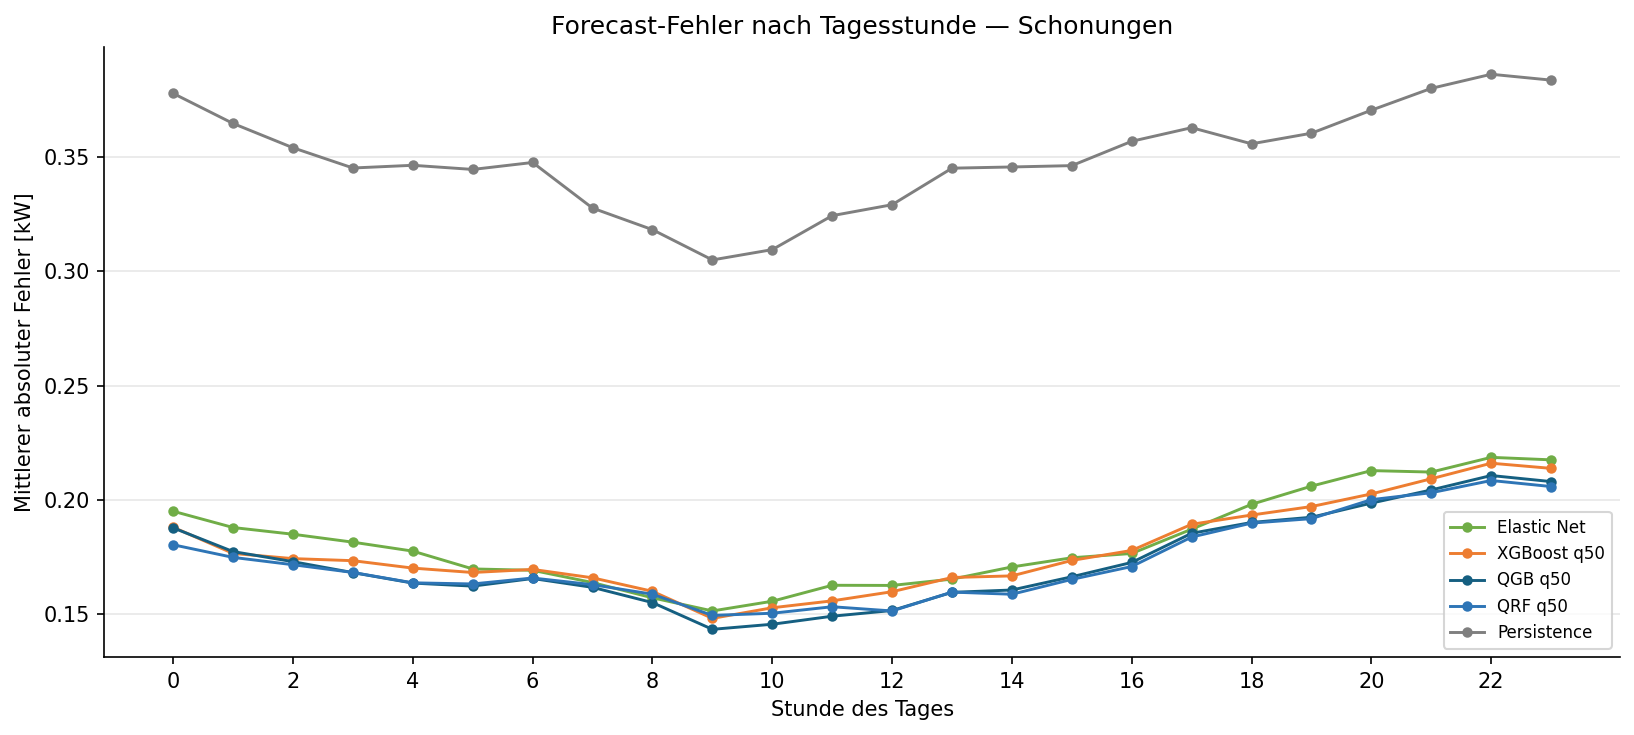

Stunde mit höchstem MAE (Elastic Net):
  Stunde 22 Uhr: 0.2 kW


In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

pred = all_predictions[PLOT_PLANT].copy()
pred["timestamp"] = pd.to_datetime(pred["timestamp"])
pred["hour"]      = pred["timestamp"].dt.hour

plot_models = [
    ("elastic_net", "Elastic Net", MODEL_COLORS["elastic_net"]),
    ("xgb_q50",     "XGBoost q50", MODEL_COLORS["xgb"]),
    ("qgb_q50",     "QGB q50",     MODEL_COLORS["qgb"]),
    ("qrf_q50",     "QRF q50",     MODEL_COLORS["qrf"]),
    ("persistence", "Persistence", MODEL_COLORS["persistence"]),
]

for col, label, color in plot_models:
    if col not in pred.columns:
        continue
    valid    = pred[col].notna()
    mae_hour = (
        pred.loc[valid]
        .assign(abs_err=lambda x: (x[col] - x["y_true"]).abs())
        .groupby("hour")["abs_err"]
        .mean()
    )
    ax.plot(mae_hour.index, mae_hour.values, marker="o", markersize=4,
            label=label, color=color, linewidth=1.4)

ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("Mittlerer absoluter Fehler [kW]")
ax.set_title(f"Forecast-Fehler nach Tagesstunde — {PLOT_PLANT}")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"mae_by_hour_{PLOT_PLANT.lower()}.png", dpi=300, bbox_inches="tight")
plt.show()

print("Stunde mit höchstem MAE (Elastic Net):")
valid = pred["elastic_net"].notna()
mae_h = (pred.loc[valid]
         .assign(e=lambda x: (x["elastic_net"]-x["y_true"]).abs())
         .groupby("hour")["e"].mean())
print(f"  Stunde {mae_h.idxmax()} Uhr: {mae_h.max():.1f} kW")
